# Logistic Regression on Diabetes 130-US Hospitals Dataset

Logistic Regression estimates the probability of a binary outcome using a sigmoid function. This notebook implements preprocessing, 60/20/20 train/validation/test split, GridSearchCV for hyperparameter tuning, and full evaluation with visualizations.

## Section 1: Data Loading and Preprocessing

- Handle missing values indicated by **"?"** (and "None")
- Remove features with >75% missing values: `weight`, `payer_code`, `medical_specialty`, `max_glu_serum`, `A1Cresult`
- **Label Engineering**: Binary classification — Readmitted (1) = "<30" or ">30", Not Readmitted (0) = "NO"

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data_cleaned.csv"
RANDOM_STATE = 42

In [2]:
# Load data; treat "?" and "None" as missing
df = pd.read_csv(DATA_PATH, na_values=["?", "None"], low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nTarget 'readmitted' distribution (before label engineering):\n{df['readmitted'].value_counts()}")

Shape: (101766, 45)

Target 'readmitted' distribution (before label engineering):
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [3]:
# Feature selection: Remove features with >75% missing values
cols_to_drop_missing = ["weight", "payer_code", "medical_specialty", "max_glu_serum", "A1Cresult"]
df = df.drop(columns=[c for c in cols_to_drop_missing if c in df.columns], errors="ignore")
print("Dropped columns (or subset):", cols_to_drop_missing)

# Drop identifier columns (not predictive)
id_cols = ["encounter_id", "patient_nbr"]
df = df.drop(columns=[c for c in id_cols if c in df.columns], errors="ignore")

# Label engineering: Binary classification
# Readmitted (1) = <30 days OR >30 days; Not Readmitted (0) = NO
def to_binary(label):
    if pd.isna(label) or str(label).strip().upper() == "NO":
        return 0
    return 1  # <30 or >30

y = df["readmitted"].apply(to_binary)
X = df.drop(columns=["readmitted"])
print(f"\nBinary target distribution:\nReadmitted (1): {y.sum()}, Not Readmitted (0): {(y == 0).sum()}")

Dropped columns (or subset): ['weight', 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult']

Binary target distribution:
Readmitted (1): 46902, Not Readmitted (0): 54864


## Section 2: Feature Engineering and Scaling

- Encode categorical features with `OneHotEncoder`
- Apply `StandardScaler` to numeric features

In [4]:
# Identify numeric vs categorical columns; drop high-cardinality diag columns for tractability
drop_cols = ["diag_1", "diag_2", "diag_3"]
X = X.drop(columns=[c for c in drop_cols if c in X.columns], errors="ignore")

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
print(f"Numeric features: {len(numeric_cols)}, Categorical features: {len(cat_cols)}")

Numeric features: 11, Categorical features: 28


/var/folders/dd/mj_wq35n4yxbxcg8pvwwyrx00000gn/T/ipykernel_10974/1722686143.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=["object"]).columns.tolist()


In [5]:
# Preprocessing pipeline: impute missing, encode categoricals, scale numeric
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, cat_cols),
], remainder="drop")

X_processed = preprocessor.fit_transform(X)
print(f"Processed feature matrix shape: {X_processed.shape}")

Processed feature matrix shape: (101766, 104)


In [6]:
# Three-way holdout: 60% train, 20% validation, 20% test (stratified by target)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_processed, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)
# 0.25 of 80% = 20% of total
print(f"Train: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 61059, Validation: 20353, Test: 20354


## Section 3: Model Training with GridSearchCV

- Use `LogisticRegression` from scikit-learn
- 5-fold cross-validation via `GridSearchCV`
- Tune regularization parameter **C** across `np.logspace(-3, 2, 10)`

In [7]:
# Hyperparameter tuning: C via GridSearchCV (5-fold CV)
param_grid = {"C": np.logspace(-3, 2, 10)}
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f"Best C: {grid_search.best_params_['C']:.6f}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best C: 2.154435
Best CV accuracy: 0.6187


## Section 4: Final Evaluation on Test Set

- Metrics: Accuracy, Precision, Recall, F1-Score, AUC
- Confusion Matrix plot
- Learning Curve plot (Training vs. Cross-Validation score)
- Prediction time

In [8]:
# Final model with best C; evaluate on held-out test set
final_model = grid_search.best_estimator_
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, zero_division=0)
recall = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, y_test_proba)

print("=== Test Set Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Not Readmitted (0)", "Readmitted (1)"]))

=== Test Set Metrics ===
Accuracy:  0.6208
Precision: 0.6387
Recall:    0.4082
F1-Score:  0.4980
AUC:       0.6577

Classification Report:
                    precision    recall  f1-score   support

Not Readmitted (0)       0.61      0.80      0.70     10973
    Readmitted (1)       0.64      0.41      0.50      9381

          accuracy                           0.62     20354
         macro avg       0.63      0.61      0.60     20354
      weighted avg       0.63      0.62      0.60     20354



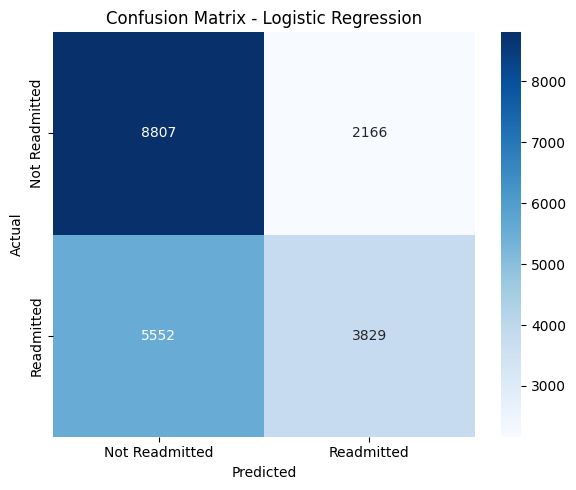

In [9]:
# Confusion Matrix plot
cm = confusion_matrix(y_test, y_test_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Not Readmitted", "Readmitted"],
            yticklabels=["Not Readmitted", "Readmitted"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

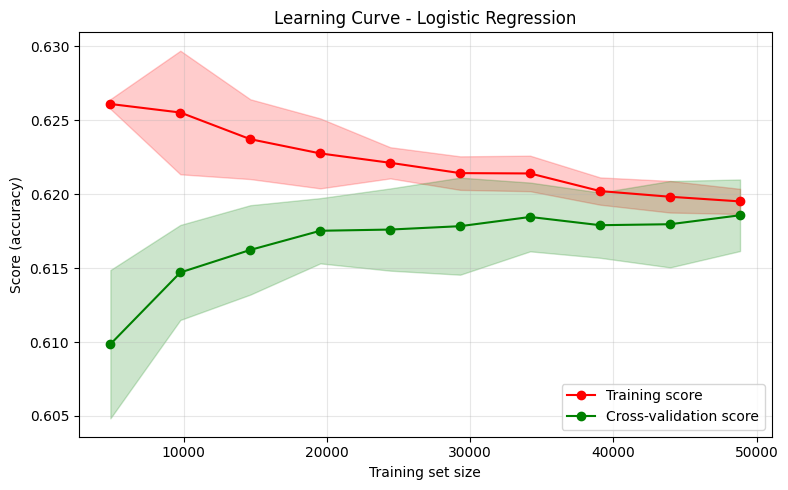

In [ ]:
# Learning Curve: Training vs. Cross-Validation score
train_sizes, train_scores, val_scores = learning_curve(
    final_model, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_mean, "o-", color="r", label="Training score")
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="r"
ax.plot(train_sizes, val_mean, "o-", color="g", label="Cross-validation score")
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color="g")
ax.set_xlabel("Training set size")
ax.set_ylabel("Score (accuracy)")
ax.set_title("Learning Curve - Logistic Regression")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Prediction time on full test set
n_repeats = 10
elapsed = []
for _ in range(n_repeats):
    t0 = time.perf_counter()
    _ = final_model.predict(X_test)
    elapsed.append(time.perf_counter() - t0)
pred_time_sec = np.mean(elapsed)
print(f"Prediction time (test set, {len(X_test)} samples, mean of {n_repeats} runs): {pred_time_sec:.4f} seconds")

Prediction time (test set, 20354 samples, mean of 10 runs): 0.0084 seconds
